<a href='https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO.github.io/blob/main/test.ipynb'>QQQQQ</a>

In [ ]:
!pip install -r requirements.txt

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
#
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import roc_auc_score,accuracy_score
#
from nilearn import datasets
from nilearn.image import index_img
import nibabel as nib
from nilearn.maskers import NiftiMasker
from nilearn import plotting, surface, datasets

In [2]:
import warnings
warnings.filterwarnings("ignore", message="The provided image has no sform in its header. "+
                        "Please check the provided file. Results may not be as expected.")

In [3]:
np.set_printoptions(legacy='1.13')

In [4]:
#compact version of dataset prep from the previous notebook
haxby_dataset = datasets.fetch_haxby()
generic_mask = nib.load(haxby_dataset.mask)
behavioral_data = pd.read_csv(haxby_dataset.session_target[0], sep=" ")
labels_mask = ((behavioral_data["labels"] == "face") | 
               (behavioral_data["labels"] == "house"))
fmri_img = index_img(haxby_dataset.func[0], labels_mask)
y = behavioral_data["labels"][labels_mask].to_numpy()
run = behavioral_data["chunks"][labels_mask].to_numpy()
test_runs = [1,2,3]
train_index = np.where(~np.isin(run, test_runs))[0]
test_index = np.where(np.isin(run, test_runs))[0]

In [5]:
#atlas: fMRI-shaped tensor containing region indices
raw_atlas = nib.load('glasser_MNI152NLin6Asym_labels_p20_resamp_haxbyresamp.nii.gz')
atlas,atlas_affine = raw_atlas.get_fdata(),raw_atlas.affine
atlas.shape

(40, 64, 64)

In [6]:
#atlas: dataframe with region infos and IDs
#the regionID here matches with the values in the atlas tensor
atlas_labels = pd.read_csv('glasser_labels2.csv')
atlas_labels

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
0,V1_L,Primary_Visual_Cortex_L,1_L,L,V1,Occ,Primary_Visual,1,1,100.491589,41.138901,71.637040,6717
1,MST_L,Medial_Superior_Temporal_Area_L,2_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,2,5,132.416667,58.901786,82.059524,336
2,V6_L,Sixth_Visual_Area_L,3_L,L,V6,Occ,Dorsal_Stream_Visual,3,3,104.543112,44.481665,103.916749,1009
3,V2_L,Second_Visual_Area_L,4_L,L,V2,Occ,Early_Visual,4,2,102.236656,44.064791,74.401125,6220
4,V3_L,Third_Visual_Area_L,5_L,L,V3,Occ,Early_Visual,5,2,107.926111,40.632159,76.961153,4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,STSva_R,Area_STSv_anterior_R,376_R,R,STSva,Temp,Auditory_Association,356,11,32.924419,117.527907,54.337791,1720
356,TE1m_R,Area_TE1_Middle_R,377_R,R,TE1m,Temp,Lateral_Temporal,357,14,26.146605,102.236497,53.246528,2592
357,PI_R,Para-Insular_Area_R,378_R,R,PI,Temp,Insular_and_Frontal_Opercular,358,12,47.013363,123.157016,57.926503,898
358,a32pr_R,Area_anterior_32_prime_R,379_R,R,a32pr,Fr,Anterior_Cingulate_and_Medial_Prefrontal,359,19,81.723096,153.990326,102.516324,827


In [7]:
#from cortex area name to masked data
def cortex_to_masked_data(area_name):
    area_indexes = atlas_labels[atlas_labels['cortex']==area_name]['regionID'].values
    boolean_mask = np.isin(atlas, area_indexes)
    nib_mask = nib.Nifti1Image(boolean_mask, 
                affine=generic_mask.affine, header=generic_mask.header)
    masked_data = NiftiMasker(mask_img=nib_mask).fit_transform(fmri_img)
    return masked_data

In [8]:
def cortex_area_ml(some_X):
    #split
    xtrn, xtst = some_X[train_index], some_X[test_index]
    ytrn, ytst = y[train_index], y[test_index]
    #train model
    local_model = RFC().fit(xtrn, ytrn)
    #evaluate scores
    local_discrete_pred = local_model.predict(xtst)
    acc = accuracy_score(ytst,local_discrete_pred)
    local_cont_pred = local_model.predict_proba(xtst)
    roc_auc = roc_auc_score((ytst==local_model.classes_[1]).astype('int'),local_cont_pred[:,1])
    return acc,roc_auc

In [9]:
results = pd.DataFrame(columns=['acc','roc_auc'])
for area_name in atlas_labels['cortex'].unique():
    masked_data = cortex_to_masked_data(area_name) 
    results.loc[area_name] = cortex_area_ml(masked_data)

In [10]:
results

,acc,roc_auc
Primary_Visual,0.518519,0.534979
MT+_Complex_and_Neighboring_Visual_Areas,0.518519,0.517147
Dorsal_Stream_Visual,0.555556,0.680384
Early_Visual,0.703704,0.859396
Ventral_Stream_Visual,0.796296,0.956790
Somatosensory_and_Motor,0.500000,0.358025
Premotor,0.481481,0.438272
Posterior_Cingulate,0.518519,0.674211
Early_Auditory,0.388889,0.357339
Temporo-Parieto_Occipital_Junction,0.537037,0.461591


In [13]:
def do_the_huge_plot(ml_results,plotted_metric):
    # Create the data tensor
    brain_centroid = np.zeros((atlas.shape))
    for area_i, area_name in enumerate(list(ml_results.index)):
        area_indexes = atlas_labels[atlas_labels['cortex']==area_name].index.values
        for area_idx in area_indexes:
            area_coord = np.where(atlas==area_idx+1)
            brain_centroid[area_coord[0], area_coord[1], area_coord[2]] = \
                ml_results.loc[area_name][plotted_metric]
    nii_img = nib.Nifti1Image(brain_centroid, atlas_affine)
    # Plot the scores over the brain
    fsaverage = datasets.fetch_surf_fsaverage()
    texture_left = surface.vol_to_surf(nii_img, fsaverage.pial_left)
    texture_right = surface.vol_to_surf(nii_img, fsaverage.pial_right)
    vmin,vmax=min(ml_results[plotted_metric]),max(ml_results[plotted_metric])
    cmap='hot'
    fig, axs = plt.subplots(2,2,subplot_kw={'projection': '3d'},figsize=(8,6))
    plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, hemi='left',
                                title='Left lateral', view='lateral',
                                axes=axs[0][0], cmap=cmap, vmin=vmin, vmax=vmax)
    plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, hemi='left',
                                title='Left medial', view='medial', 
                                axes=axs[1][0], cmap=cmap, vmin=vmin, vmax=vmax)
    plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, hemi='right',
                                title='Right lateral', view='lateral', 
                                axes=axs[0][1], cmap=cmap, vmin=vmin, vmax=vmax)
    plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, hemi='right',
                                title='Right medial', view='medial', 
                                axes=axs[1][1], cmap=cmap, vmin=vmin, vmax=vmax)
    plotting.show()

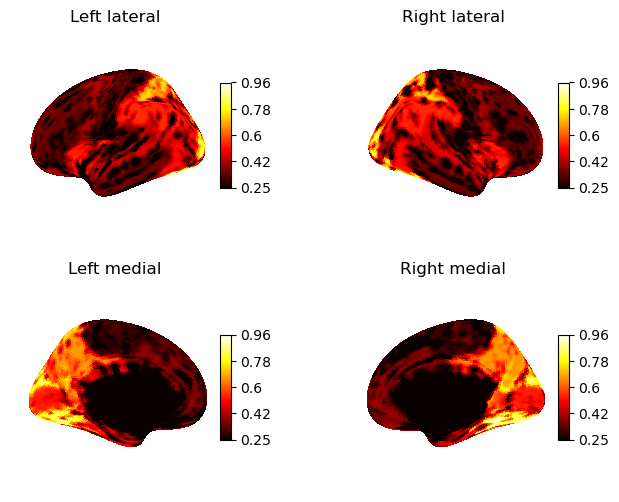

In [14]:
do_the_huge_plot(ml_results=results,plotted_metric='roc_auc')